# **Лабораторная №1**
# *Исмаилова Камила М80-308Б-23*

**ПОДГОТОВКА - БАЗОВЫЕ ШТУЧКИ** 🦊





**Импорт необходимых библиотек, инструментов**


In [59]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.interpolate import make_interp_spline
import statsmodels.api as sm
warnings.filterwarnings('ignore')

**Загрузка данных**



In [60]:
df_train = pd.read_csv("train.csv")
df_train_test = pd.read_csv("test.csv")
test_id = df_train_test['ID'].copy()

df_train.drop_duplicates(inplace=True)
df_train.dropna(inplace=True)

df_train_original = df_train.copy()


работа с пропусками другими способами : средним, медианой или модой давали либо Такой же MSE, либо хуже.


**Борьба с  выбросами**


Посмотрим на наличие выбросов с помощью boxplot

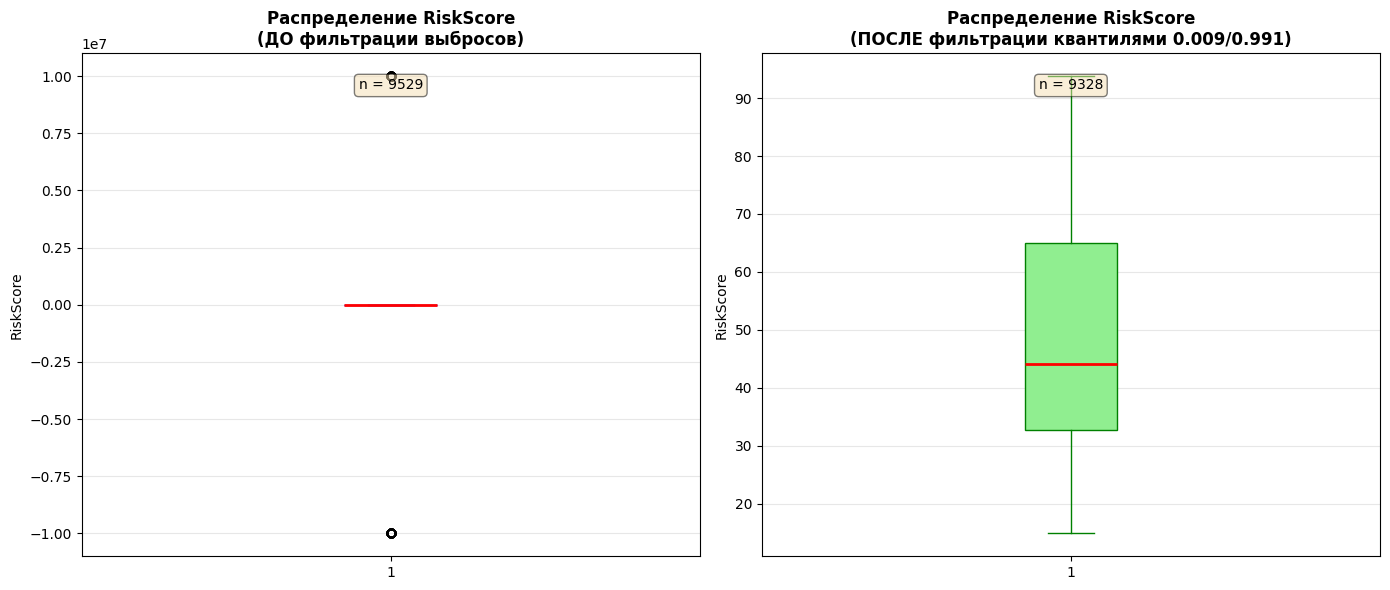

In [61]:
df_train_original = df_train.copy()


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].boxplot(df_train_original['RiskScore'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='blue'),
                capprops=dict(color='blue'))
axes[0].set_title('Распределение RiskScore\n(ДО фильтрации выбросов)', 
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('RiskScore')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].text(0.5, 0.95, f'n = {len(df_train_original)}', 
             transform=axes[0].transAxes, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


qn, qf = df_train['RiskScore'].quantile([0.009, 0.991])
df_train = df_train[(df_train['RiskScore'] > qn) & (df_train['RiskScore'] < qf)]


axes[1].boxplot(df_train['RiskScore'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='green'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='green'),
                capprops=dict(color='green'))
axes[1].set_title('Распределение RiskScore\n(ПОСЛЕ фильтрации квантилями 0.009/0.991)', 
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('RiskScore')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].text(0.5, 0.95, f'n = {len(df_train)}', 
             transform=axes[1].transAxes, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('riskscore_compare.png', dpi=300, bbox_inches='tight')
plt.show()

Наличие окружностей - наличие выбросов, причем на очень большом расстоянии от основного распределения. Выбросы могут перетягивать все на себя. Из за доминатности может пострадать MSE.
Квантиль находит экстремальные значения и удаляет.

Даже с учетом последующих преобразований отсутствие обработки выбросов приведет к **MSE**: 2025294037787.6772

Оптимальный - до 1%.

- [0.005, 0.995] MSE:23.5456
- [0.009, 0.991] MSE:24.6520
- [0.01, 0.99]   MSE:24.6520
- [0.001, 0.999] MSE:24.5456
- [0.008, 0.992] MSE:24.5456

Видно что ухудшения начинаются уже с 0.9 %. Ниже 0.8% результат одинаковый скорее всего из за маленбкого количества уникальных значений в экстремальных областях.  Рассматривать ниже 0.1% нет смысла так как Pandas не может различить квантили мельче 1/n. n = 10 000.

Возьмем условно посередине [0.005, 0.995]

In [62]:
df_train.shape

(9328, 35)

**Кореляционная матрица и другие графики** 🦊

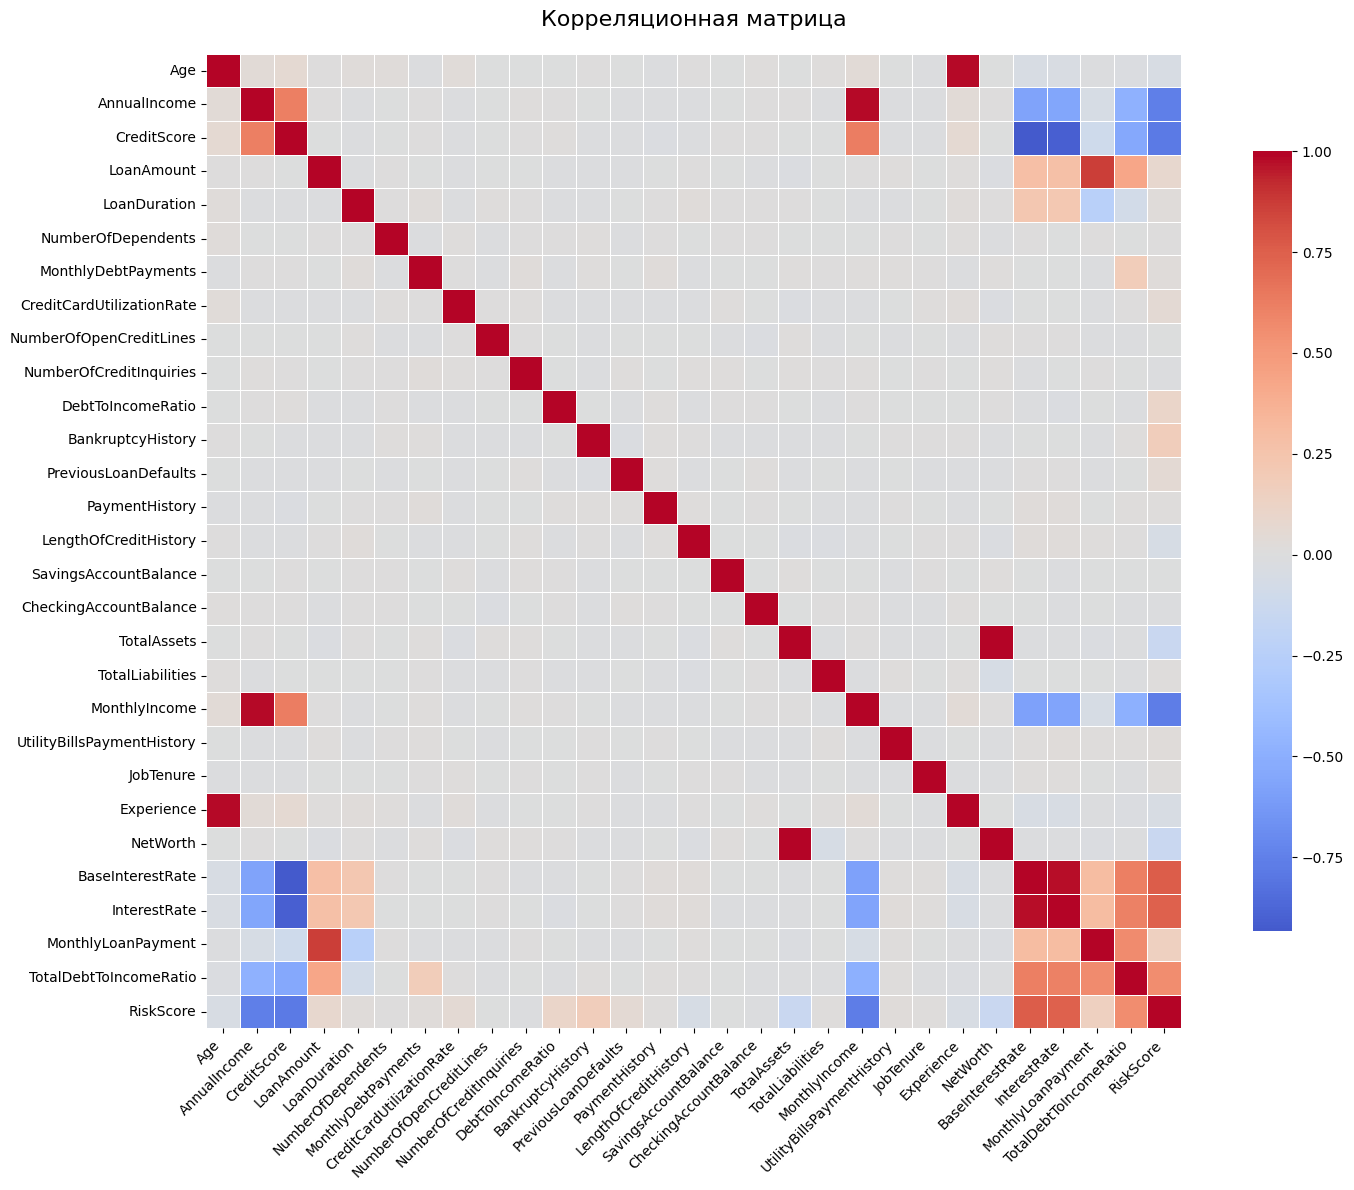

In [63]:
numeric_df_train = df_train.select_dtypes(include='number')

plt.figure(figsize=(16, 12))
heatmap = sns.heatmap(numeric_df_train.corr(), 
                     annot=False, 
                     cmap='coolwarm', 
                     center=0,
                     square=True,
                     linewidths=0.5,
                     cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

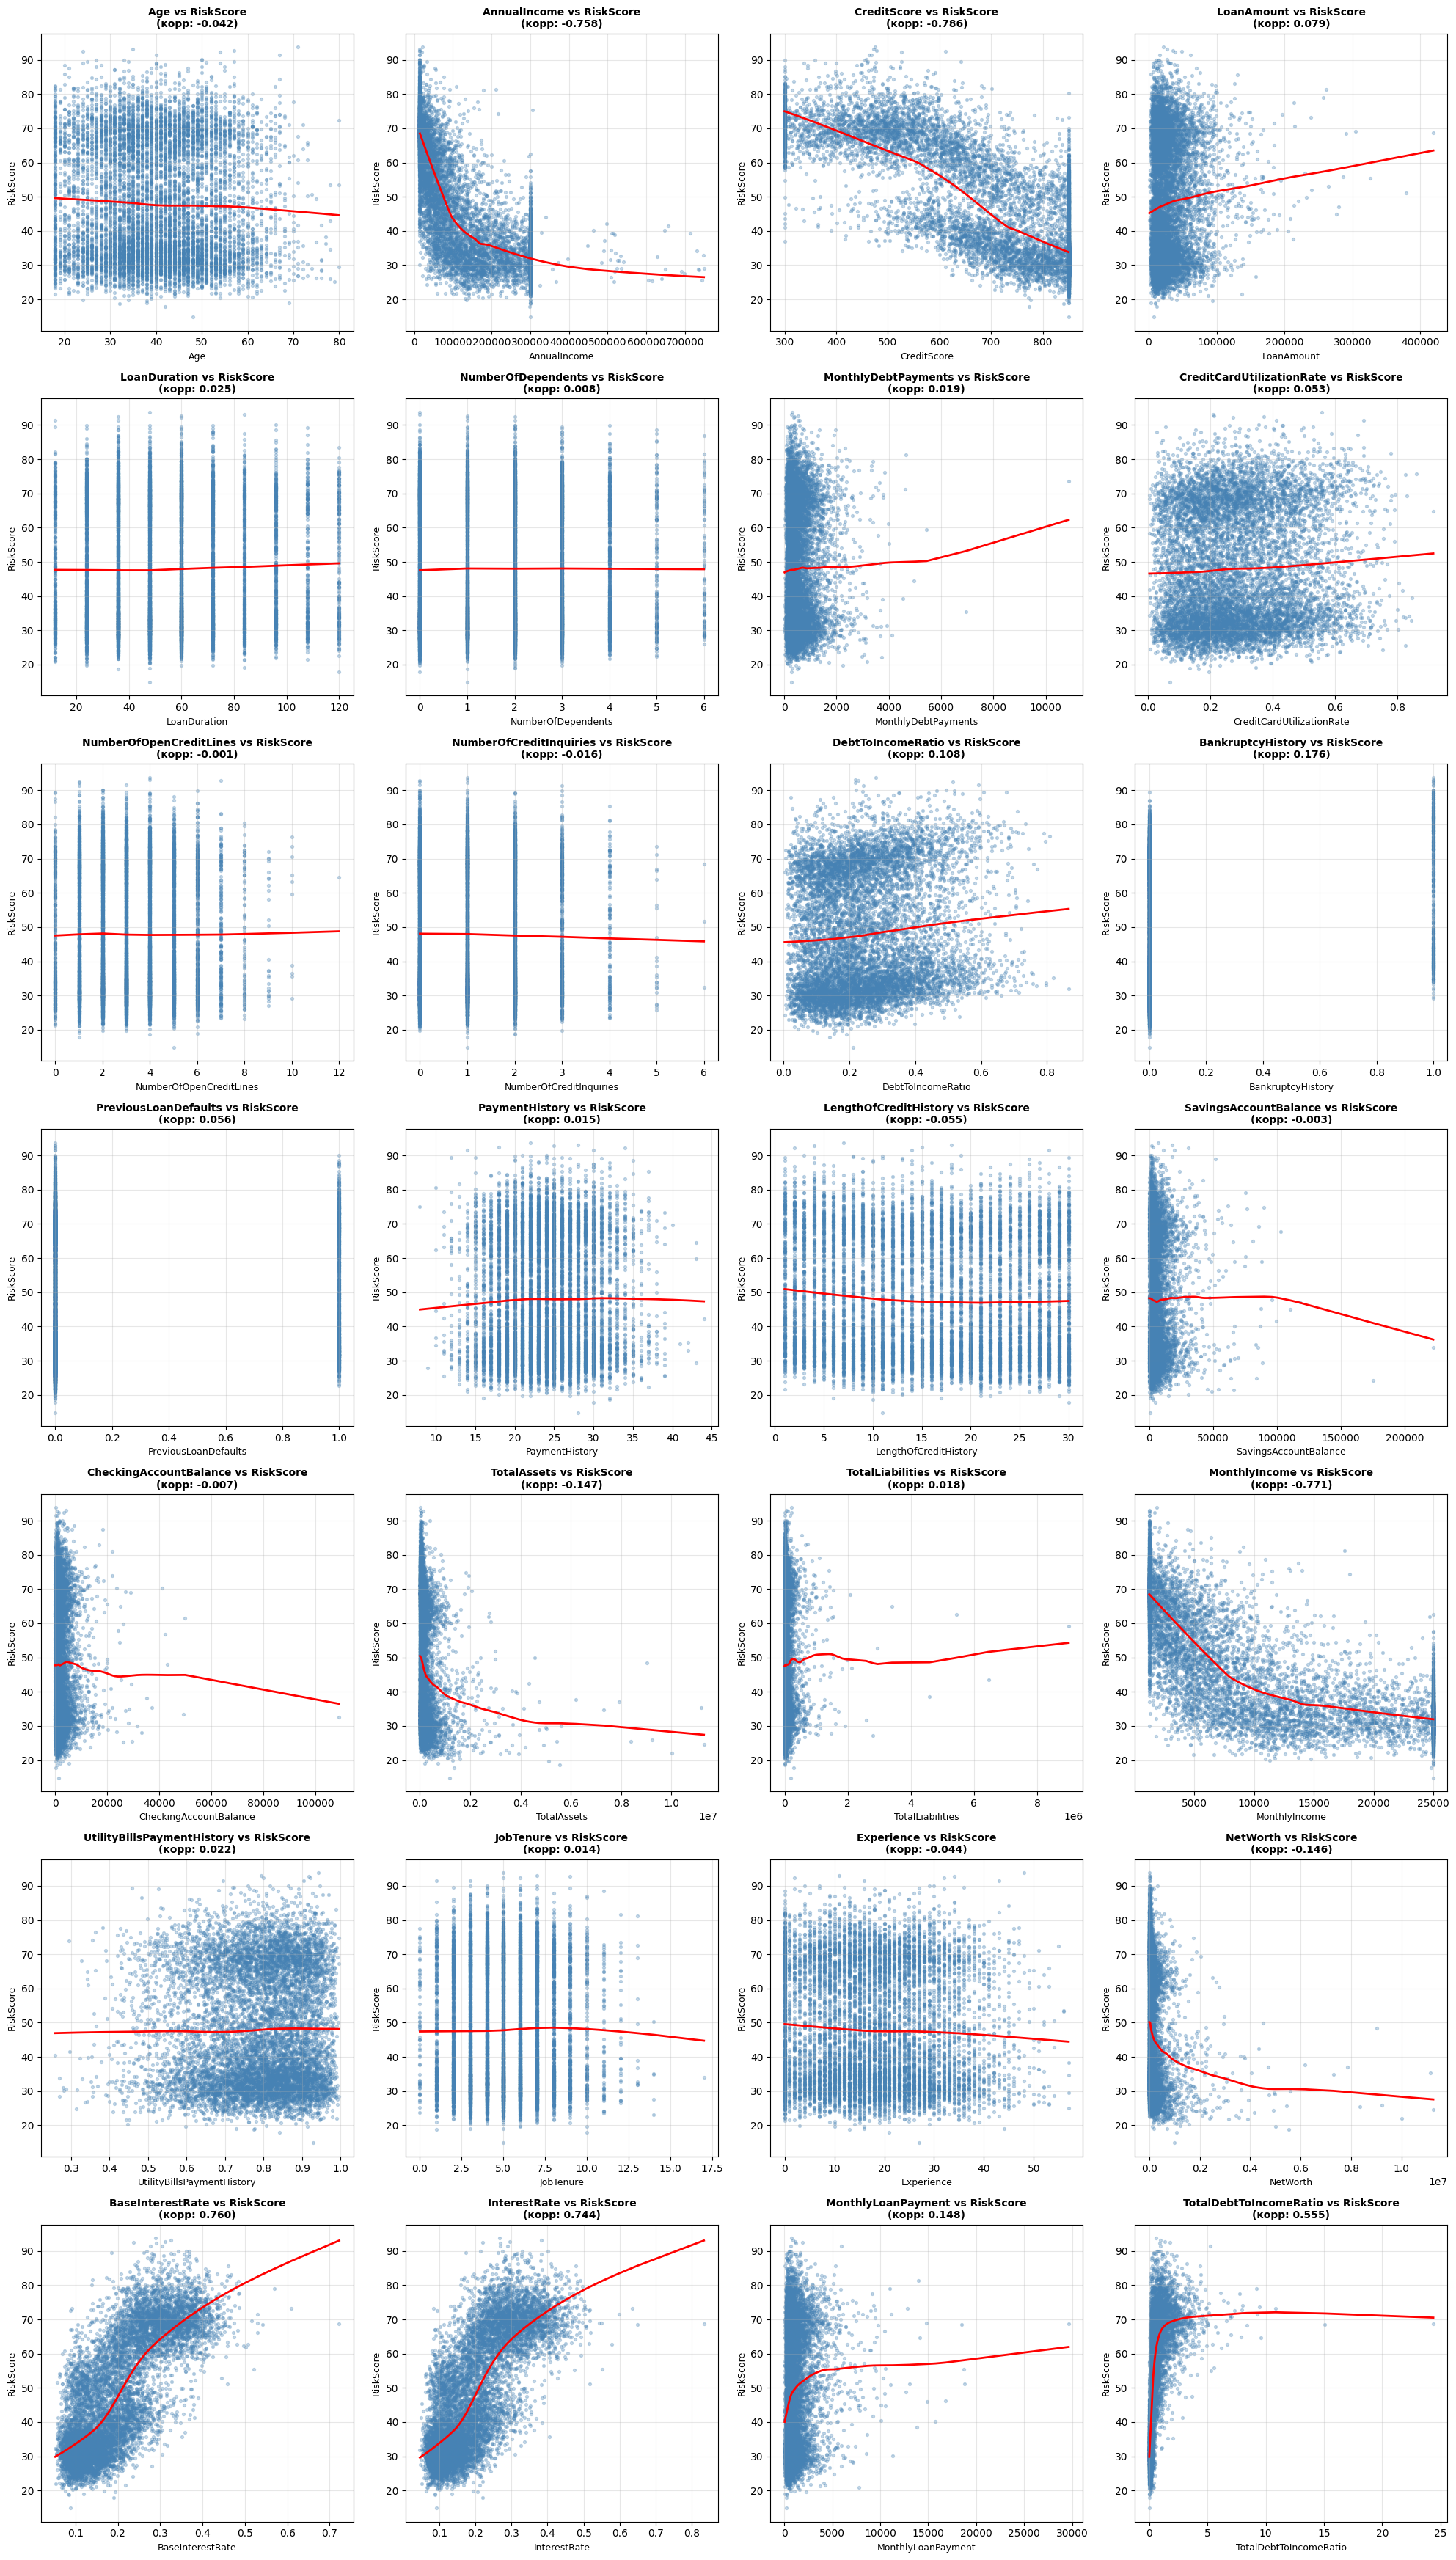

In [64]:
s_features = [col for col in numeric_df_train.columns if col not in ['RiskScore', 'ID']]

n_features = len(s_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(s_features):
    axes[idx].scatter(df_train[feature], df_train['RiskScore'], alpha=0.3, s=8, color='steelblue')
    if df_train[feature].nunique() > 5:
        try:
            sns.regplot(x=feature, y='RiskScore', data=df_train, ax=axes[idx],
                        scatter=False, lowess=True, color='red', line_kws={'linewidth': 2})
        except Exception as e:
            print(f"Не удалось построить LOWESS для '{feature}': {e}")
    corr_value = df_train[feature].corr(df_train['RiskScore'])
    axes[idx].set_title(f'{feature} vs RiskScore\n(корр: {corr_value:.3f})', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=9)
    axes[idx].set_ylabel('RiskScore', fontsize=9)
    axes[idx].grid(True, alpha=0.3)

for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('scatter_all.png', dpi=300, bbox_inches='tight')
plt.show()


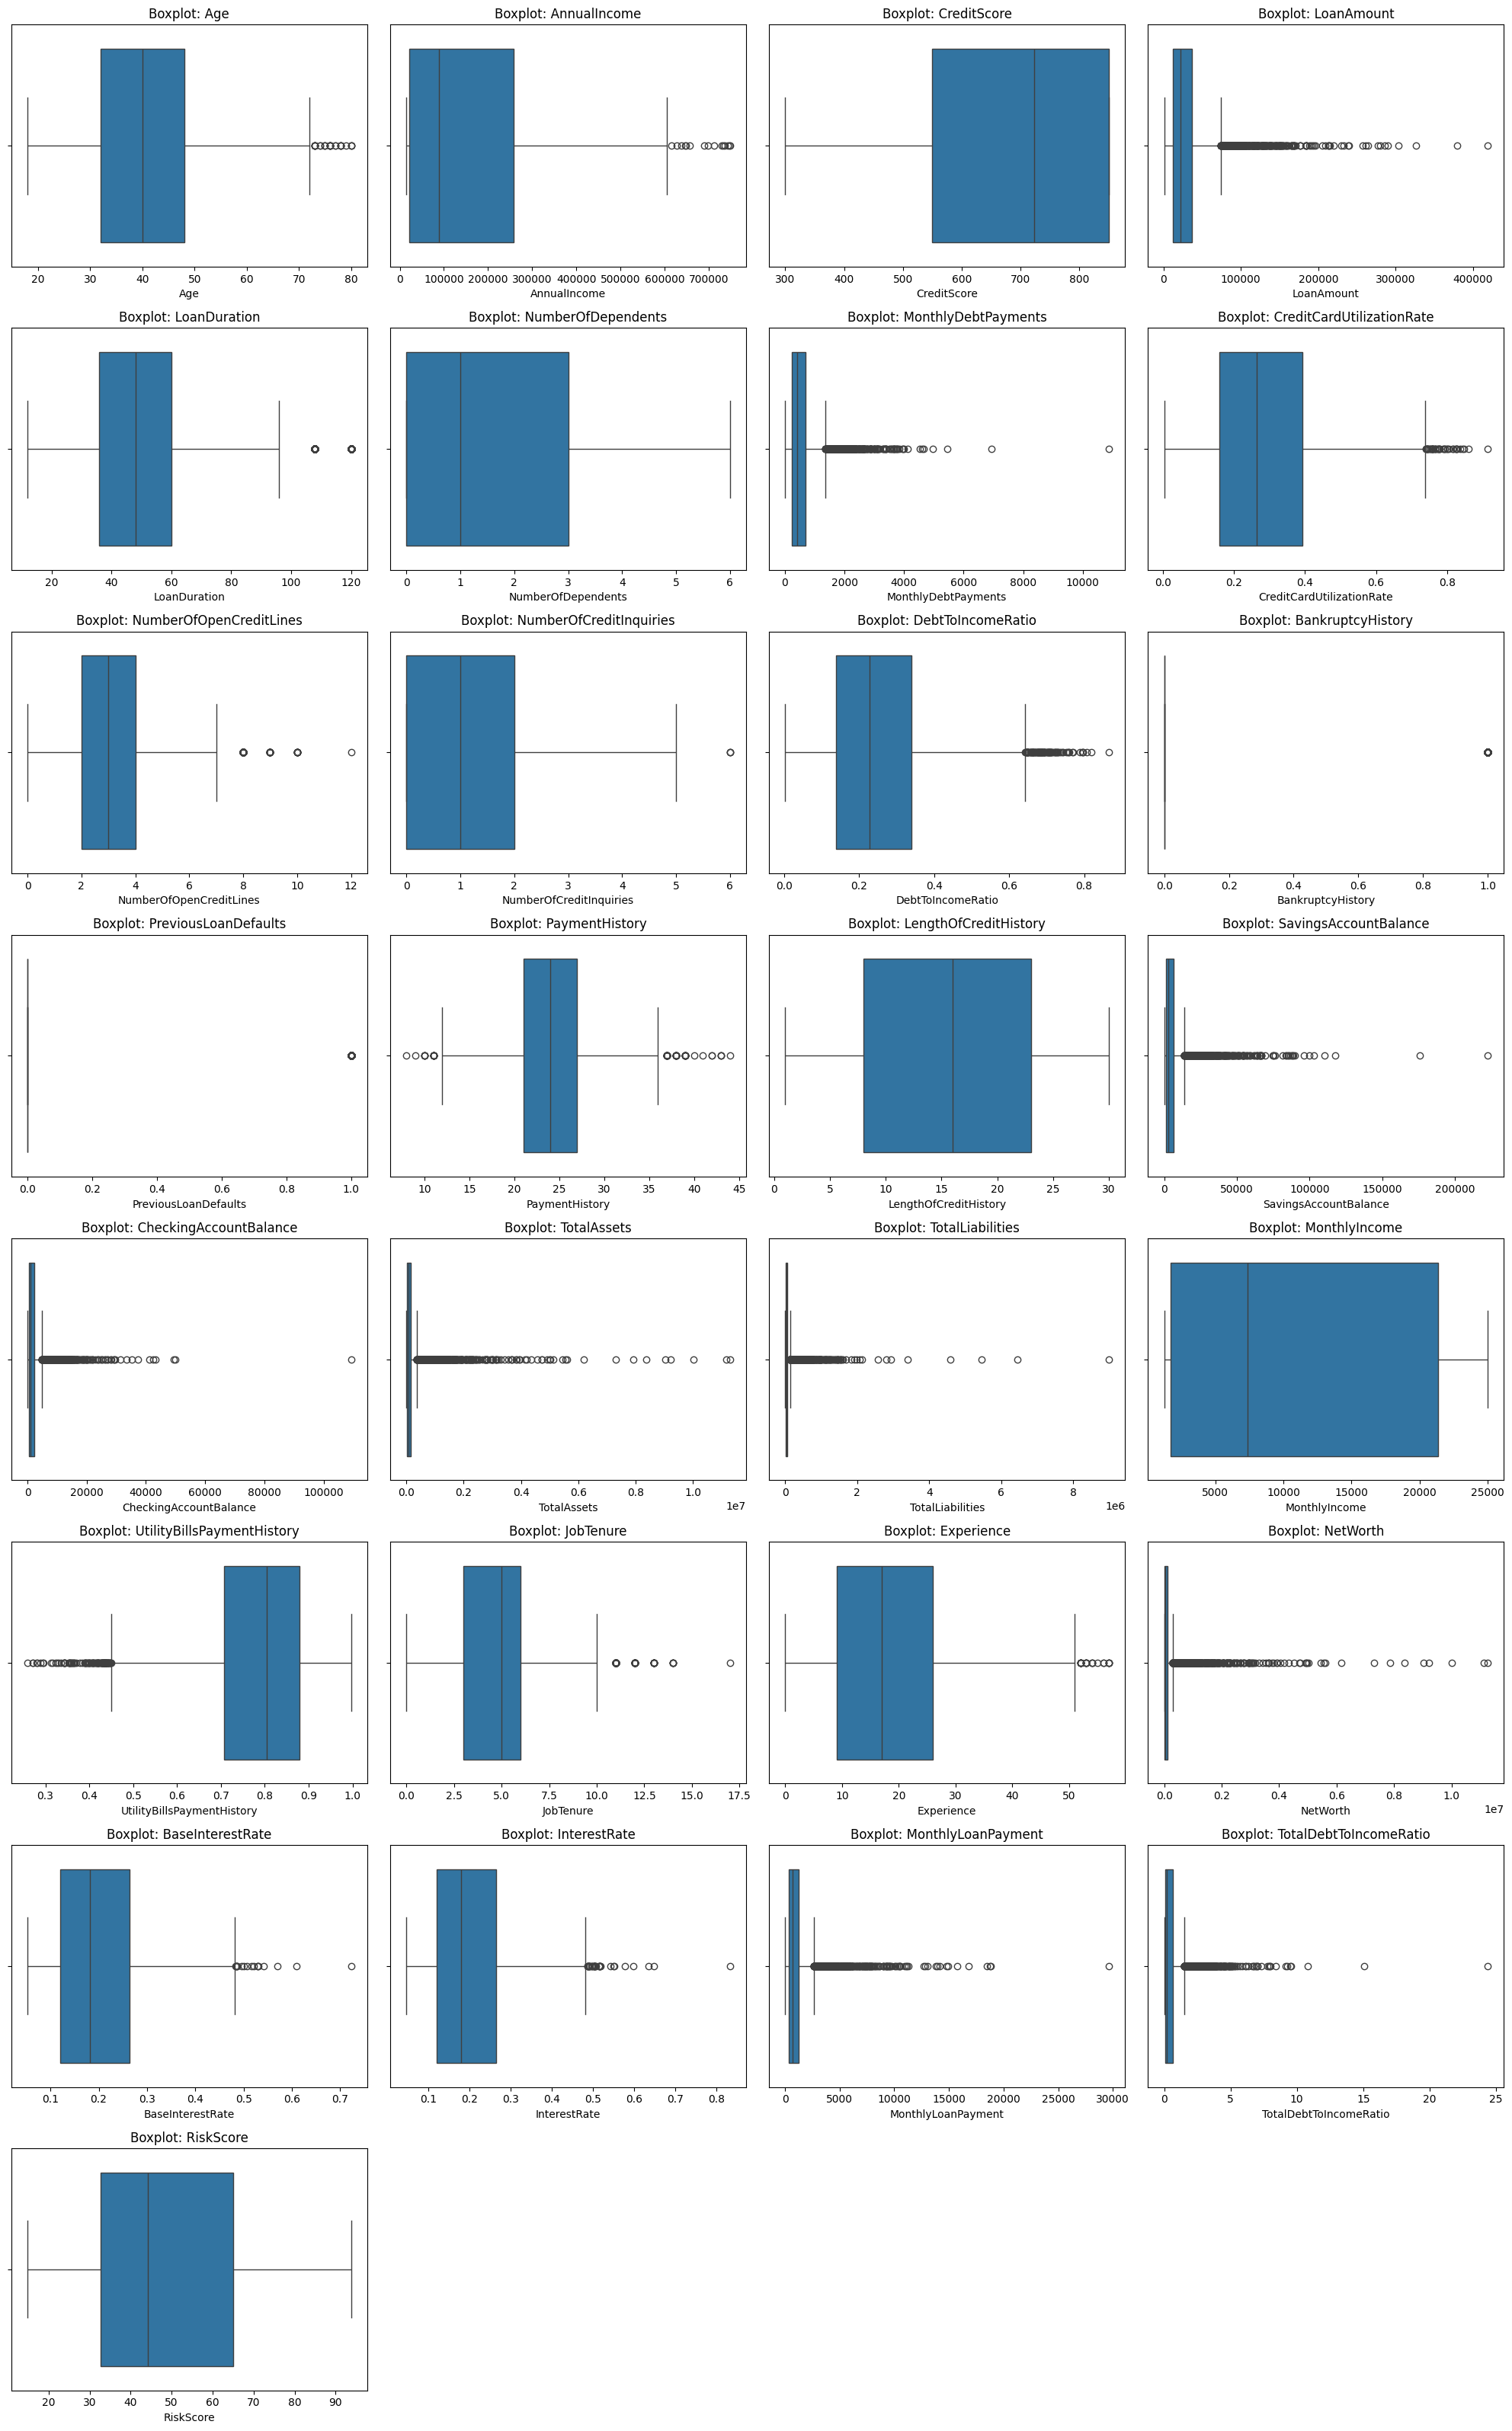

In [65]:
b_features = df_train.select_dtypes(include='number').columns.tolist()
if 'ID' in b_features:
    b_features.remove('ID')

n_features = len(b_features)
n_cols = 4 
n_rows = (n_features + n_cols - 1) // n_cols 
b_features = df_train.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(b_features):
    sns.boxplot(x=df_train[col], ax=axes[idx])
    axes[idx].set_title(f'Boxplot: {col}')

for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('boxplots_all.png', dpi=300, bbox_inches='tight')
plt.show()



**Обработка** 🦊

In [66]:
def bining_preprocess(df_in):
    df = df_in.copy()

    df  = df.drop('ApplicationDate', axis=1, errors='ignore')

    df['Age_cat'] = pd.cut(df['Age'], bins=[0, 25, 35, 50, 65, 100], labels=['very_young', 'young', 'middle', 'senior', 'old'])
    df = pd.get_dummies(df, columns=['Age_cat'], drop_first=True)


    df['Credit_tier'] = pd.cut(df['CreditScore'], bins=[0, 600, 700, 800, 1000], labels=['poor', 'fair', 'good', 'excellent'])
    df = pd.get_dummies(df, columns=['Credit_tier'], drop_first=True)


    df['Income_level'] = pd.qcut(df['MonthlyIncome'], q=4, labels=['low', 'medium', 'high', 'very_high'],  duplicates='drop')
    df = pd.get_dummies(df, columns=['Income_level'], drop_first=True)

    df = pd.get_dummies(df, columns=['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel'], drop_first=True)
    return df


БИНИНГ. Данные три категории можно визуально поделить на категории, с которыми грубо говоря работаем отдельною. Выбросы не так сильно влияют и мы можем уловить резкий переход. Я так же пробовала применить для некоторых других параметров применить бининг(например:AnnualIncome, но тогда MSE незначительно,но увеличивался). 

In [67]:
def category_preprocess(df):
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    return df

По факту тут просходит One-Hot Encoding. При просмотре датасета  к категориальным признакам будуь отнесены: EmploymentStatus, EducationLeve, LoanPurpose, MaritalStatus,HomeOwnershipStatus.
Но я на всякий случай добавила имено отбор через object category

In [68]:
def create_financial_datas(df):
    df = df.copy()
    df['DebtBurdenIndicator'] = df['MonthlyDebtPayments'] / (df['MonthlyIncome'] + 1) #процент от дохода за месяц, который идет на долги
    df['AssetToIncome'] = df['TotalAssets'] / (df['AnnualIncome'] + 1) #отношение активов к доходу за год
    df['MonthSaving'] = df['SavingsAccountBalance'] / (df['MonthlyIncome'] + 1 ) #сбережения
    df['LoanToIncome'] = df['LoanAmount'] / (df['AnnualIncome'] + 1) #отношение кредита к доходу

    return df

Создаем дополнительные признаки,для большей информативности. Без доп параметров MSE застревал на 50 

In [69]:
def mathop_preprocess(df):
    df = df.copy()
    log_features = ['AnnualIncome', 'LoanAmount', 'NetWorth', 'TotalDebtToIncomeRatio', 'MonthlyLoanPayment', 'CreditScore', 'MonthlyIncome', 'BaseInterestRate']
    for feat in log_features:
        if feat in df.columns:
            df[f'{feat}_log'] = np.log1p(df[feat])
    sqrt_features = ['TotalDebtToIncomeRatio', 'CreditScore', 'NetWorth', 'MonthlyIncome', 'TotalAssets']
    for feat in sqrt_features:
        if feat in df.columns:
            df[f'{feat}_sqrt'] = np.sqrt(df[feat])
    cbrt_features = ['TotalDebtToIncomeRatio', 'CreditScore', 'NetWorth', 'TotalAssets']
    for feat in cbrt_features:
        if feat in df.columns:
            df[f'{feat}_cbrt'] = np.cbrt(df[feat])
    inverse_features = ['InterestRate', 'BaseInterestRate', 'CreditScore']
    for feat in inverse_features:
        if feat in df.columns:
            df[f'{feat}_inv'] = 1 / (df[feat] + 0.001)
    return df

- Логарифмируем указанные параметры так как  кривая имеют вид логарифмической функции. Так же есть хвосты - где данные находятся не в основной куче
- Возводим в квдратный корень. Так как некоторые кривые похоже на функцию корня.
- Кубический корень. Сгущение на концах(правых), у нуля. Много маленьких значений- мало больших
- 1/x где есть "линейная зависимость"

Некоторые операции применены к одному и тому же признаку - так как выравниванеи смещения не получается сделать эффективно только одним преобразованием.

In [70]:
def add_interactions_and_poly(df):
    df = df.copy()
    interactions = [
        ('TotalAssets_sqrt', 'InterestRate', 'mul'),
        ('TotalAssets_sqrt', 'InterestRate', 'div'),
        ('TotalAssets_sqrt', 'TotalDebtToIncomeRatio', 'mul'),
        ('TotalAssets_sqrt', 'TotalDebtToIncomeRatio', 'div'),
        ('TotalAssets_sqrt', 'BaseInterestRate', 'mul'),
        ('TotalAssets_sqrt', 'MonthlyLoanPayment', 'mul'),
        ('TotalAssets_sqrt', 'MonthlyLoanPayment', 'div'),
        ('TotalAssets_sqrt', 'BankruptcyHistory', 'mul'),
        ('MonthlyIncome_sqrt', 'InterestRate', 'mul'),
        ('MonthlyIncome_sqrt', 'InterestRate', 'div'),
        ('MonthlyIncome_sqrt', 'TotalDebtToIncomeRatio', 'mul'),
        ('MonthlyIncome_sqrt', 'TotalDebtToIncomeRatio', 'div'),
        ('MonthlyIncome_sqrt', 'BaseInterestRate', 'mul'),
        ('MonthlyIncome_sqrt', 'MonthlyLoanPayment', 'mul'),
        ('MonthlyIncome_sqrt', 'MonthlyLoanPayment', 'div'),
        ('MonthlyIncome_sqrt', 'BankruptcyHistory', 'mul'),
        ('DebtServiceRatio', 'InterestRate', 'mul'),
        ('AssetToIncomeRatio', 'LoanAmount', 'div'),
        ('LoanToIncome', 'InterestRate', 'mul'),
        ('BaseInterestRate', 'MonthlyLoanPayment', 'div'),
        ('MonthlyIncome', 'InterestRate', 'div'),
        ('MonthlyIncome', 'BaseInterestRate', 'div'),
        ('LoanAmount', 'InterestRate', 'div'),
        ('CreditCardUtilizationRate', 'InterestRate', 'mul'),
    ]
    for feat1, feat2, op in interactions:
        if feat1 in df.columns and feat2 in df.columns:
            if op == 'mul':
                df[f'{feat1}_mul_{feat2}'] = df[feat1] * df[feat2]
            elif op == 'div':
                df[f'{feat1}_div_{feat2}'] = df[feat1] / (df[feat2] + 1e-6)
    features_to_poly = [
        'BaseInterestRate', 'InterestRate', 'TotalDebtToIncomeRatio',
        'DebtToIncomeRatio', 'MonthlyLoanPayment', 'CreditScore', 'MonthlyIncome',
        'LengthOfCreditHistory', 'DebtServiceRatio', 'LoanToIncome'
    ]
    for feature in features_to_poly:
        if feature in df.columns:
            df[f'{feature}_2'] = df[feature] ** 2
            df[f'{feature}_3'] = df[feature] ** 3
    return df


Делаем некое взаимодействиемежду парметрами. Некоторые из комбинаций могут влять сильнее чем по отдельности, тогда выясняются новые закономерности.
Полиномы помогают обойти проблемы с изгибами в кривой распределения

In [71]:
def preprocess_pipeline(df):
    df = df.drop('ApplicationDate', axis=1, errors='ignore')
    df = bining_preprocess(df)
    df = category_preprocess(df)
    df = create_financial_datas(df)
    df = mathop_preprocess(df)
    df = add_interactions_and_poly(df)
    return df


In [72]:
y_full = df_train['RiskScore'].copy()
X_full_raw = preprocess_pipeline(df_train.drop('RiskScore', axis=1, errors='ignore'))


**Корреляционная матрица после преобразований** 🦊

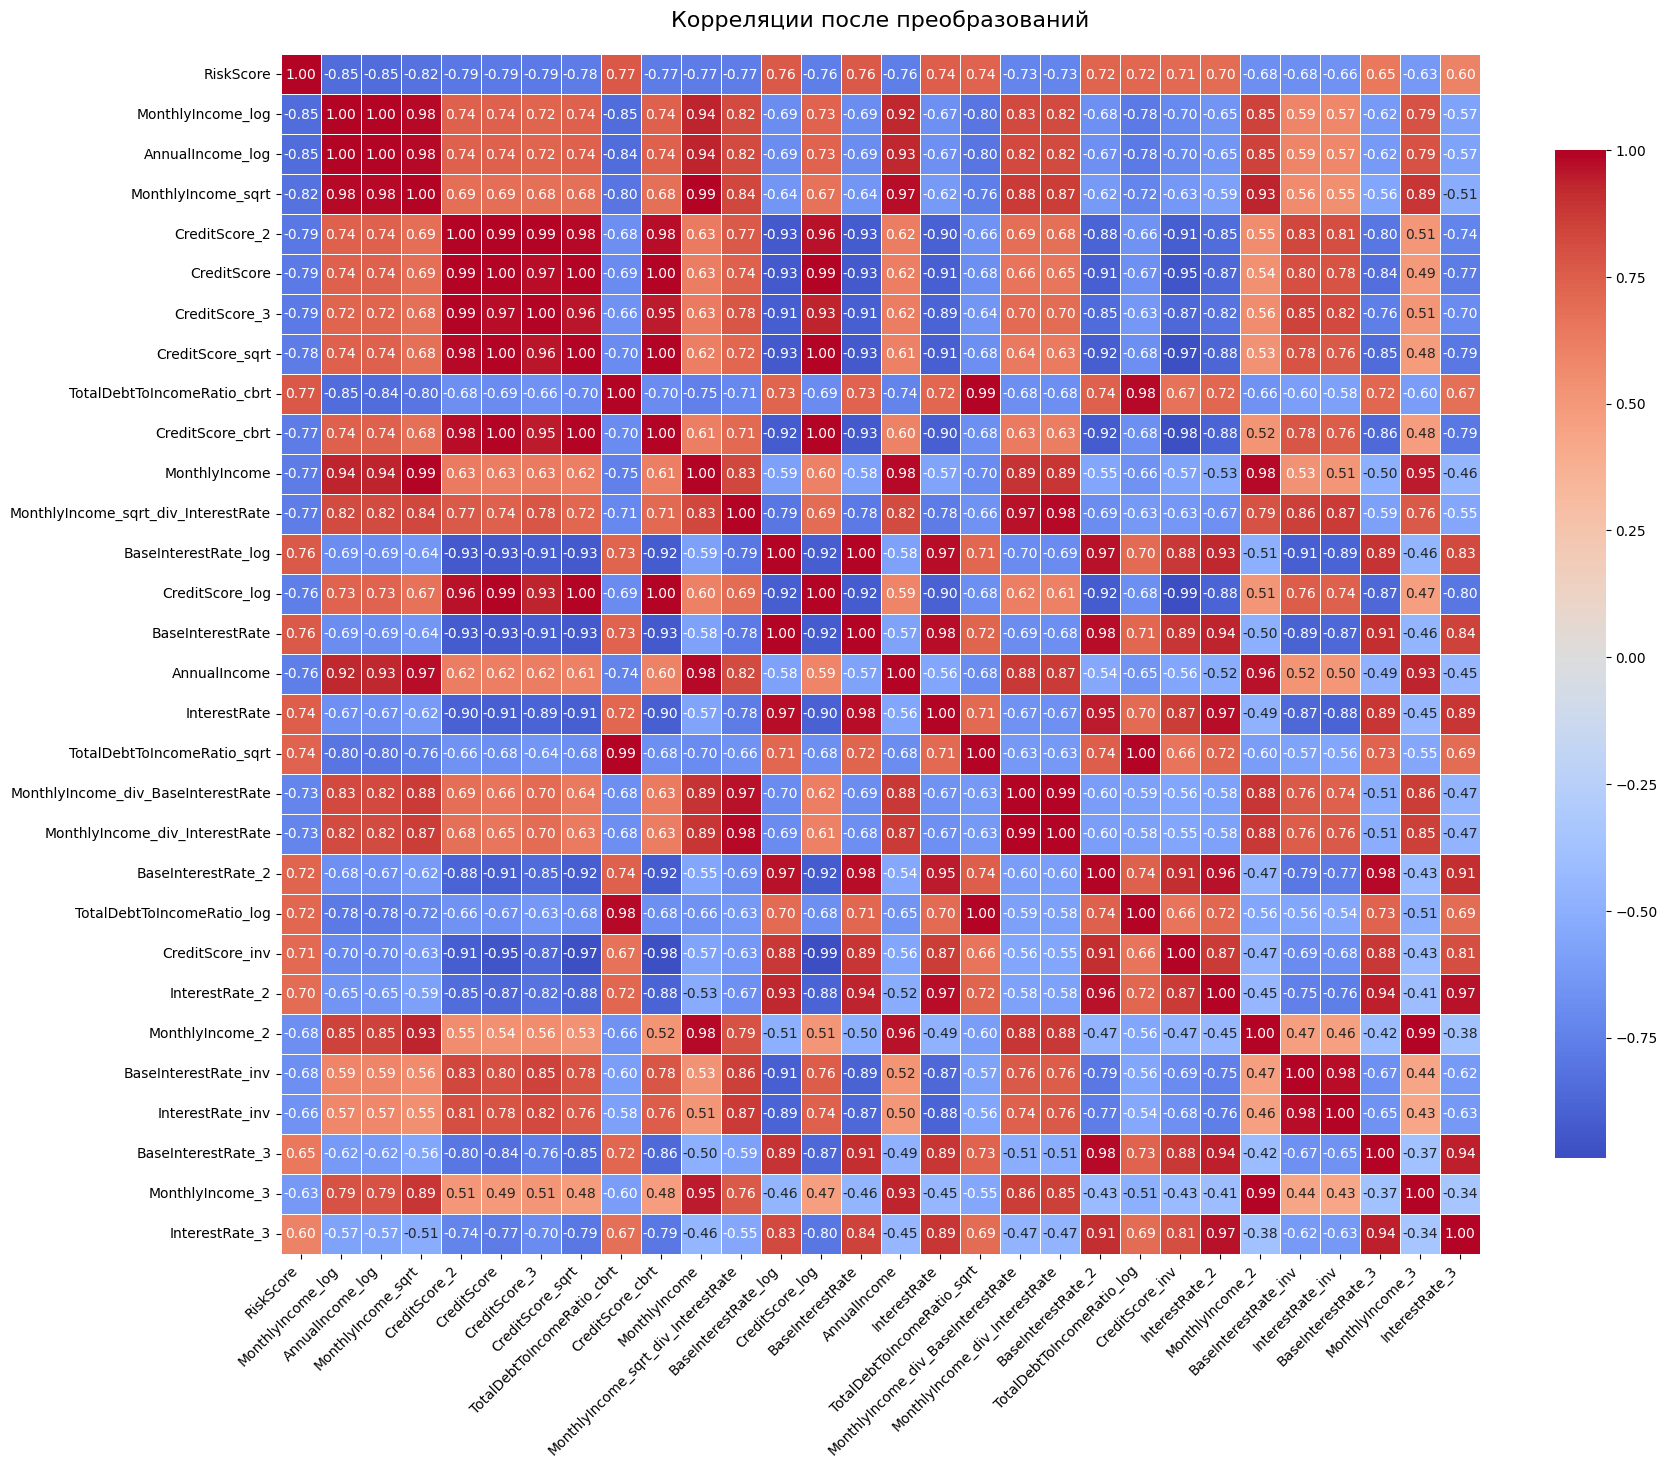

In [73]:
corr_post = X_full_raw.copy()
corr_post['RiskScore'] = df_train['RiskScore'].values


corr_matrix = corr_post.corr()
top_features = corr_matrix['RiskScore'].abs().sort_values(ascending=False).head(30).index


plt.figure(figsize=(18, 15))
heatmap_fe = sns.heatmap(corr_post[top_features].corr(), 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})
plt.title('Корреляции после преобразований', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_matrix_after', dpi=300, bbox_inches='tight')
plt.show()

**Boxplot после бининга** 🦊


медианы находятся в разных местах примерно везде - значит бининг был не напрасен. В age он будто бы не нужен . Но он влияет на сотые доли в MSE

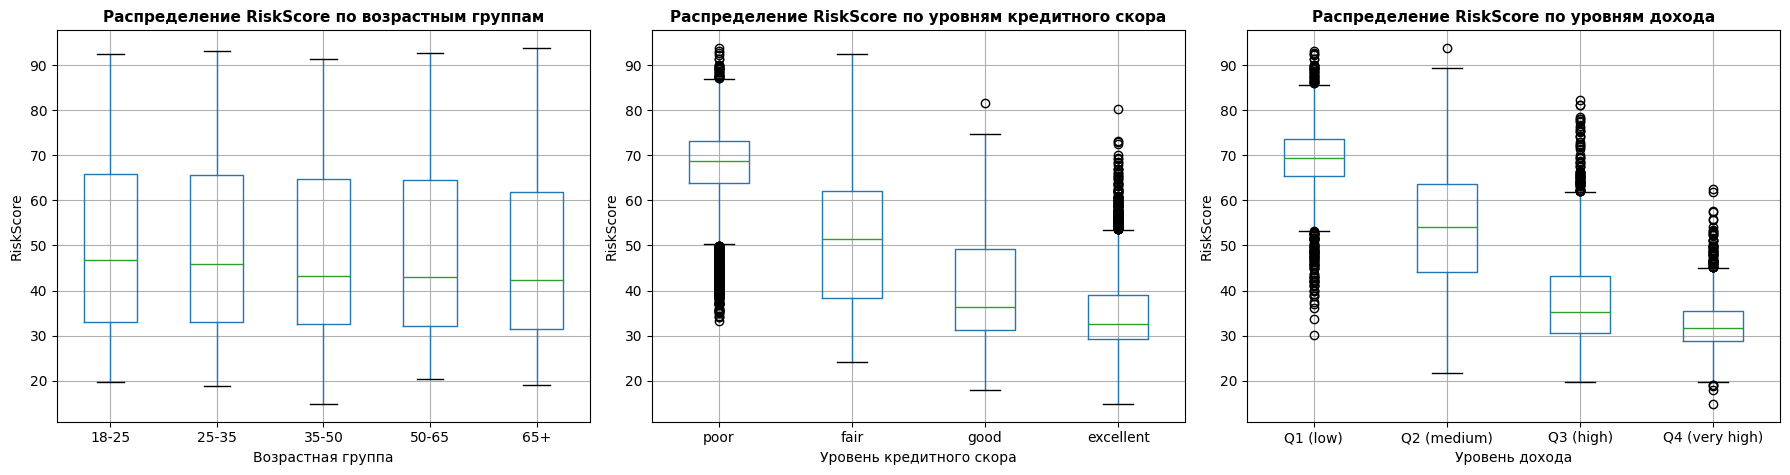

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

binned_age = pd.cut(df_train['Age'], bins=[0, 25, 35, 50, 65, 100], labels=['18-25', '25-35', '35-50', '50-65', '65+'])
df_plot_age = pd.DataFrame({'Age_group': binned_age, 'RiskScore': df_train['RiskScore']})
df_plot_age.boxplot(column='RiskScore', by='Age_group', ax=axes[0])
axes[0].set_title('Распределение RiskScore по возрастным группам', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Возрастная группа')
axes[0].set_ylabel('RiskScore')
axes[0].get_figure().suptitle('')

binned_credit = pd.cut(df_train['CreditScore'], bins=[0, 600, 700, 800, 1000], labels=['poor', 'fair', 'good', 'excellent'])
df_plot_credit = pd.DataFrame({'Credit_tier': binned_credit, 'RiskScore': df_train['RiskScore']})
df_plot_credit.boxplot(column='RiskScore', by='Credit_tier', ax=axes[1])
axes[1].set_title('Распределение RiskScore по уровням кредитного скора', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Уровень кредитного скора')
axes[1].set_ylabel('RiskScore')
axes[1].get_figure().suptitle('')


binned_income = pd.qcut(df_train['MonthlyIncome'], q=4, labels=['Q1 (low)', 'Q2 (medium)', 'Q3 (high)', 'Q4 (very high)'],  duplicates='drop')
df_plot_income = pd.DataFrame({'Income_level': binned_income, 'RiskScore': df_train['RiskScore']})
df_plot_income.boxplot(column='RiskScore', by='Income_level', ax=axes[2])
axes[2].set_title('Распределение RiskScore по уровням дохода', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Уровень дохода')
axes[2].set_ylabel('RiskScore')
axes[2].get_figure().suptitle('')


plt.tight_layout()
plt.savefig('binning_after.png', dpi=300, bbox_inches='tight')
plt.show()

**Финальная подготовка и выбор модели** 🦊

In [75]:
from sklearn.linear_model import Ridge, LinearRegression, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100

X_tr_raw, X_val_raw, y_tr, y_val = train_test_split(X_full_raw, y_full, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_raw)
X_val_scaled = scaler.transform(X_val_raw)

alphas_to_test = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
best_alpha = None
best_val_mse = float('inf')
for alpha in alphas_to_test:
    model = Ridge(alpha=alpha)
    model.fit(X_tr_scaled, y_tr)
    pred_val = model.predict(X_val_scaled)
    mse_val = mean_squared_error(y_val, pred_val)
    print(f"Ridge alpha={alpha:7.3f}\tMSE: {mse_val:.4f}")
    if mse_val < best_val_mse:
        best_val_mse = mse_val
        best_alpha = alpha

models = {
    'LinearRegression': LinearRegression(),
    f'Ridge (alpha={best_alpha:.3f})': Ridge(alpha=best_alpha),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5)
}

best_model_name = None
best_model_mse = float('inf')
best_model_obj = None

for name, model in models.items():
    model.fit(X_tr_scaled, y_tr)
    pred_val = model.predict(X_val_scaled)
    mse = mean_squared_error(y_val, pred_val)
    mae = mean_absolute_error(y_val, pred_val)
    r2 = r2_score(y_val, pred_val)
    mape = mean_absolute_percentage_error(y_val, pred_val)
    print(f"\n{name:20s}\tMSE: {mse:.4f}\tMAE: {mae:.4f}\tR2: {r2:.4f}\tMAPE: {mape:.2f}%")
    if mse < best_model_mse:
        best_model_mse = mse
        best_model_name = name
        best_model_obj = model

final_scaler = StandardScaler()
X_full_scaled = final_scaler.fit_transform(X_full_raw)
best_model_obj.fit(X_full_scaled, y_full)

X_test_raw = preprocess_pipeline(df_train_test.drop('ID', axis=1, errors='ignore'))
X_test_raw = X_test_raw.reindex(columns=X_full_raw.columns, fill_value=0)
X_test_scaled = final_scaler.transform(X_test_raw)

test_predictions = best_model_obj.predict(X_test_scaled)
test_predictions = np.clip(test_predictions, 0, 100)

submission = pd.DataFrame({'ID': test_id, 'RiskScore': test_predictions})
submission.to_csv('\nl.csv', index=False)
print(f"l.csv ")
print(best_model_name)


Ridge alpha=  0.001	MSE: 24.7583
Ridge alpha=  0.010	MSE: 24.8786
Ridge alpha=  0.050	MSE: 25.1039
Ridge alpha=  0.100	MSE: 25.1802
Ridge alpha=  0.500	MSE: 25.2663
Ridge alpha=  1.000	MSE: 25.2767

LinearRegression    	MSE: 24.6983	MAE: 3.7414	R2: 0.9147	MAPE: 8.62%

Ridge (alpha=0.001) 	MSE: 24.7583	MAE: 3.7524	R2: 0.9145	MAPE: 8.64%

Lasso               	MSE: 25.5104	MAE: 3.8603	R2: 0.9119	MAPE: 8.89%

ElasticNet          	MSE: 25.6674	MAE: 3.8750	R2: 0.9114	MAPE: 8.93%
l.csv 
LinearRegression


В итоге не смотря на риск мультиколлениарности линейная регрессия все равно оказалась лучше
Показатели по основным метрикам так же не показывают проблем